# Example Juvenile Knockout Session for Dandiset 001699

This notebook demonstrates how to stream and explore data from a juvenile Fmr1 knockout rat session in [DANDI:001699](https://dandiarchive.org/dandiset/001699/draft). The dataset contains extracellular electrophysiology recordings from juvenile and adult rats performing exploration and sleep tasks in a cylindrical open-field arena.

We showcase the following data streams:
- [Subject and session metadata](#metadata)
- [Task epochs](#epochs)
- [Position tracking](#tracking)
- [Sleep classification](#sleep)
- [Raw electrophysiology and LFP](#ephys)
- [Spike-sorted units](#units)
- [Histology images](#histology)

# Streaming the NWB file <a id="stream-nwb"></a>

We use the DANDI API to stream the NWB file directly without downloading it.

In [1]:
from stream_nwbfile import stream_nwbfile

dandiset_id = "001699"
file_path = "sub-H3016/sub-H3016_ses-210422_behavior+ecephys+image.nwb"
nwbfile, io = stream_nwbfile(dandiset_id, file_path)
nwbfile

Data type,uint8
Shape,"(0, 0, 0)"
Array size,0.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),0
Compressed size (bytes),0
Compression ratio,undefined
Data type,float64
Shape,"(298996,)"


# Subject and session metadata <a id="metadata"></a>

This is a juvenile Fmr1 knockout rat (subject H3016). The session consists of exploration and sleep epochs in a cylindrical open-field arena.

In [2]:
nwbfile.subject

subject pynwb.file.Subject at 0x13226498368
Fields:
  age__reference: birth
  date_of_birth: 2021-03-31 00:00:00+01:00
  description: All experimental procedures were carried out under a UK Home Office project licence, approved by the Animal Welfare and Ethical Review Board (AWERB) of the University of Edinburgh College of Medicine and Veterinary Medicine, and conformed with the UK Animals (Scientific Procedures) Act 1986. Long-Evans male Fmr1-/y and WT rat littermates were bred in-house by crossing WT sires with Fmr1-heterozygous dams. The original null mutants were generated using zinc finger nucleases targeting Fmr1 exon 1 with a construct containing the sequence coding for eGFP. The Fmr1-/y males from the resulting line do not express either FMRP or eGFP, as described in 4. The rats used for the experiments described in this thesis were bred in-house and were housed with their parents and siblings up until weaning at postnatal day 21 (P21). After weaning, animals were housed with their littermates. They were kept on a 12h/12h light/dark cycle (lights on at 7am) and fed ad libitum on standard laboratory chow, with supplementation of water-soaked breeding chow after the surgery. 24 hours after the end of the surgery, adult rats were placed on mild food restriction to encourage foraging, with their body weight not falling below 90% of their free feeding weight. Pairs of rats (i.e. 1 WT and 1 Fmr1-/y rat) were randomly allocated to the experiment from the litter. Experimenters were blind to the genotype of the animals chosen throughout experiments including surgery, recordings, and pre-processing, and were unblinded to conduct statistical comparisons between groups.
  genotype: KO
  sex: M
  species: Rattus norvegicus
  strain: Long-Evans_Fmr1
  subject_id: H3016

In [3]:
print(f"Session description: {nwbfile.session_description}")
print(f"Session start time: {nwbfile.session_start_time}")
print(f"Experiment description: {nwbfile.experiment_description}")

Session description: Exploration, sleep and cue rotation 
Session start time: 2021-04-22 18:15:24+01:00
Experiment description: Basic properties of the head-direction system


# Task epochs <a id="epochs"></a>

Each session consists of multiple epochs corresponding to different behavioral tasks: exploration (wake), sleep, and exploration with a rotated visual cue (wake_cue_rot). The epochs are stored in `nwbfile.epochs` and the task metadata is in `nwbfile.processing["tasks"]`.

In [4]:
epochs_df = nwbfile.epochs.to_dataframe()
epochs_df

,start_time,stop_time,tags
id,,,
0,0.000000,1263.846367,[01]
1,1306.197333,6818.542900,[02]
2,6861.952000,8097.220233,[03]
3,8401.305600,9890.798900,[04]


In [5]:
# Display task descriptions
for task_name in nwbfile.processing["tasks"].data_interfaces:
    task_table = nwbfile.processing["tasks"][task_name]
    print(f"Task: {task_name}")
    print(f"  Description: {task_table['task_description'][0]}")
    print(f"  Environment: {task_table['task_environment'][0]}")
    print()

Task: sleep
  Description: The rat was given a 90-minute sleep opportunity in a container placed inside the recording arena, during which recordings continued.
  Environment: sleep_container

Task: wake
  Description: The rat was awake and foraging for scattered cereal in a cylindrical open field. The recording environment consisted of a cylindrical arena of 73 cm diameter, with 54 cm tall walls, painted light blue. A prominent visual cue was positioned at the top of the wall on the north side; this was 31.5 cm wide and 26 cm tall and consisted of two black horizontal stripes with a white stripe between them.
  Environment: cylindrical_open_field

Task: wake_cue_rot
  Description: The rat was awake and foraging for scattered cereal in a cylindrical open field. The recording environment consisted of a cylindrical arena of 73 cm diameter, with 54 cm tall walls, painted light blue. A prominent visual cue was positioned at the top of the wall on the north side; this was 31.5 cm wide and 26

# Position tracking <a id="tracking"></a>

Position data is stored in `nwbfile.processing["behavior"]["Position"]`. The processed position is in centimeters, with the origin at the bottom-left corner of the arena.

In [6]:
import numpy as np

position = nwbfile.processing["behavior"]["Position"]["position"]
print(f"Position data shape: {position.data.shape}")
print(f"Unit: {position.unit}")
print(f"Reference frame: {position.reference_frame}")
print(f"Number of timestamps: {position.timestamps.shape[0]}")

Position data shape: (159545, 2)
Unit: centimeters
Reference frame: (0,0) origin at bottom left corner.
Number of timestamps: 159545


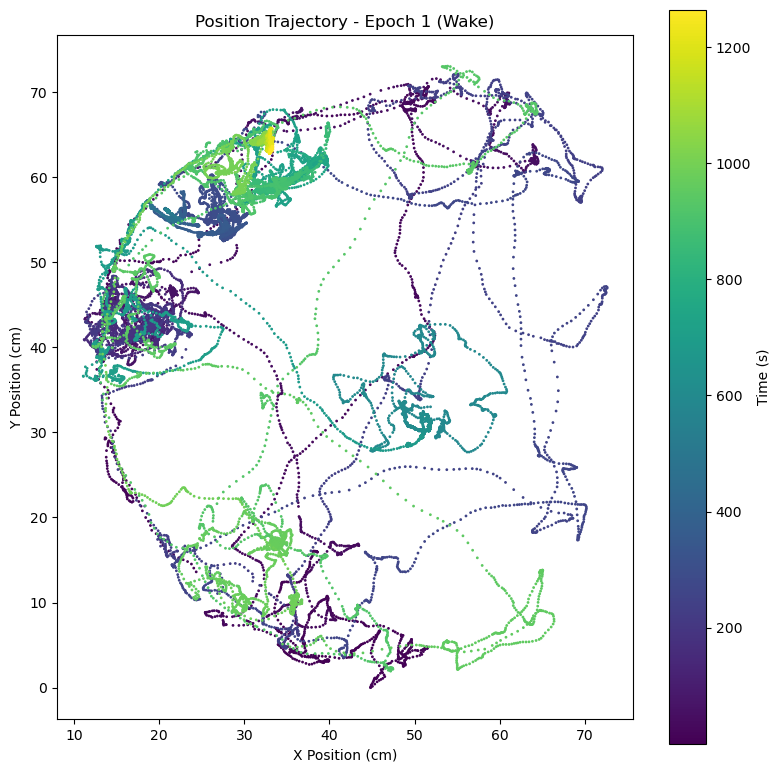

In [7]:
import matplotlib.pyplot as plt

# Plot position trajectory for the first epoch (wake exploration)
epoch1_start = epochs_df.iloc[0]["start_time"]
epoch1_stop = epochs_df.iloc[0]["stop_time"]

timestamps = np.asarray(position.timestamps[:])
position_data = np.asarray(position.data[:])
epoch1_mask = (timestamps >= epoch1_start) & (timestamps <= epoch1_stop)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    position_data[epoch1_mask, 0],
    position_data[epoch1_mask, 1],
    c=timestamps[epoch1_mask],
    cmap="viridis",
    s=1,
)
ax.set_xlabel("X Position (cm)")
ax.set_ylabel("Y Position (cm)")
ax.set_title("Position Trajectory - Epoch 1 (Wake)")
ax.set_aspect("equal")
plt.colorbar(scatter, label="Time (s)")
plt.tight_layout()

# Sleep classification <a id="sleep"></a>

Sleep stages (NREM, REM, Wake) are stored in `nwbfile.intervals["sleep_stages"]`. We can visualize them alongside the epoch structure.

In [8]:
sleep_stages = nwbfile.intervals["sleep_stages"].to_dataframe()
sleep_stages.head(10)

,start_time,stop_time,tags
id,,,
0,1.000767,513.000767,[wake]
1,514.000767,554.000767,[nrem]
2,555.000767,583.000767,[wake]
3,584.000767,596.000767,[nrem]
4,597.000767,1105.000767,[wake]
5,1106.000767,1114.000767,[nrem]
6,1115.000767,1135.000767,[wake]
7,1136.000767,1164.000767,[nrem]
8,1165.000767,1181.000767,[wake]


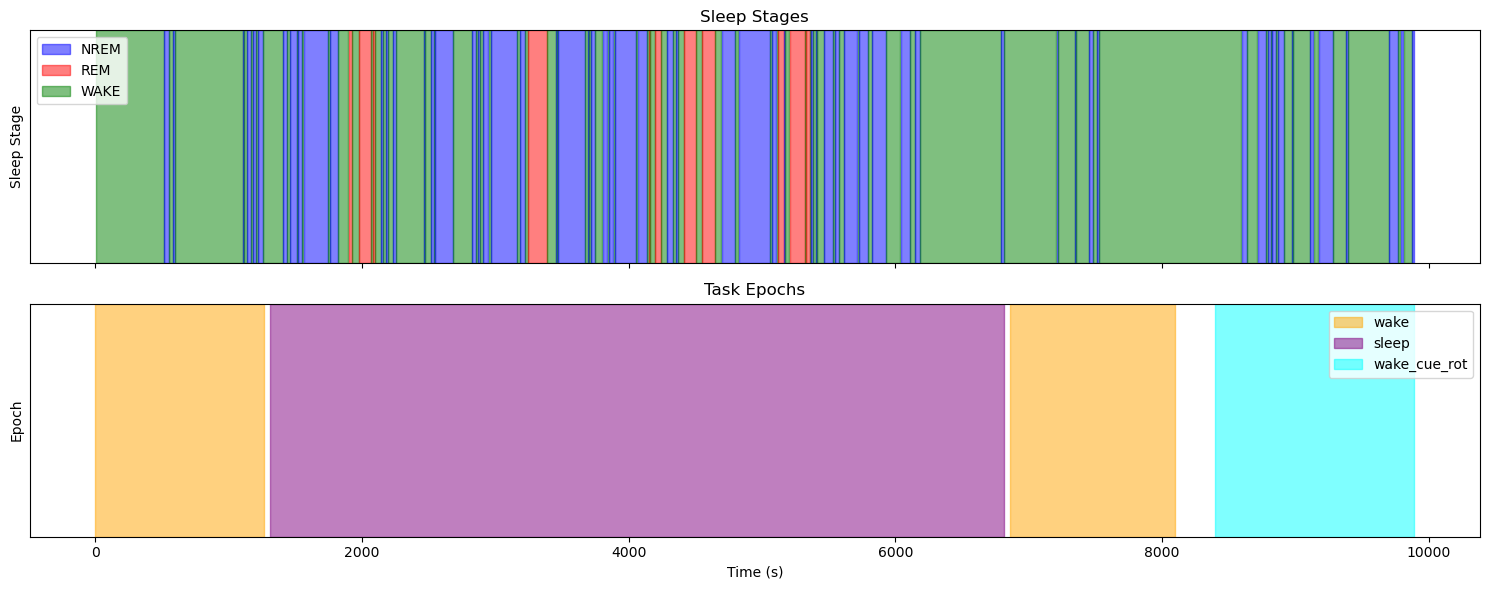

In [9]:
stage_colors = {"nrem": "blue", "rem": "red", "wake": "green"}

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

# Top subplot: Sleep stages
for _, row in sleep_stages.iterrows():
    axes[0].axvspan(row["start_time"], row["stop_time"], alpha=0.5, color=stage_colors[row["tags"][0]])

handles = [plt.Rectangle((0, 0), 1, 1, color=color, alpha=0.5) for color in stage_colors.values()]
axes[0].legend(handles, [s.upper() for s in stage_colors.keys()])
axes[0].set_ylabel("Sleep Stage")
axes[0].set_yticks([])
axes[0].set_title("Sleep Stages")

# Bottom subplot: Task epochs
epoch_colors = {"wake": "orange", "sleep": "purple", "wake_cue_rot": "cyan"}
used_labels = set()
for _, row in epochs_df.iterrows():
    tag = str(int(row["tags"][0])) # '01' -> '1'
    for task_name, task_table in nwbfile.processing["tasks"].data_interfaces.items():
        if tag in task_table["task_epochs"][0]:
            label = task_name if task_name not in used_labels else None
            axes[1].axvspan(row["start_time"], row["stop_time"], alpha=0.5, color=epoch_colors[task_name], label=label)
            used_labels.add(task_name)
            break

axes[1].legend()
axes[1].set_ylabel("Epoch")
axes[1].set_yticks([])
axes[1].set_title("Task Epochs")
axes[1].set_xlabel("Time (s)")
plt.tight_layout()

# Raw electrophysiology and LFP <a id="ephys"></a>

Raw electrophysiology data (30 kHz) is stored in `nwbfile.acquisition["e-series"]`. The LFP (downsampled) is in `nwbfile.processing["ecephys"]["LFP"]["LFP"]`. We plot a 5-second window from a single channel.

In [10]:
from bisect import bisect_left

raw_electrical_series = nwbfile.acquisition["e-series"]
lfp_electrical_series = nwbfile.processing["ecephys"]["LFP"]["LFP"]

print(f"Raw data shape: {raw_electrical_series.data.shape}")
print(f"Raw conversion to volts: {raw_electrical_series.conversion}")
print(f"LFP data shape: {lfp_electrical_series.data.shape}")
print(f"LFP conversion to volts: {lfp_electrical_series.conversion}")

Raw data shape: (285028608, 32)
Raw conversion to volts: 1.9499999284744263e-07
LFP data shape: (11876192, 32)
LFP conversion to volts: 1.9499999284744263e-07


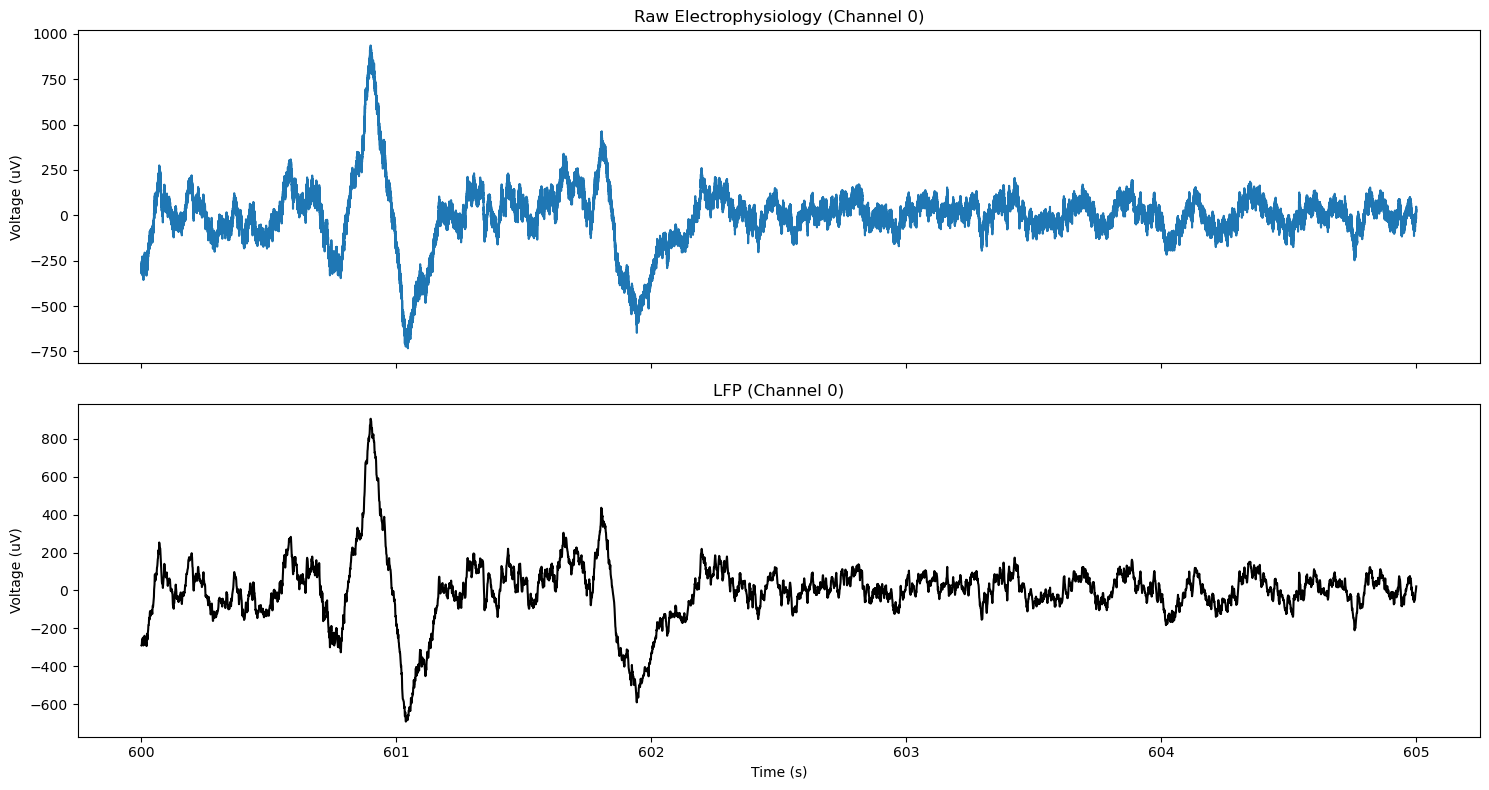

In [11]:
# Plot a 5-second window of raw ephys and LFP for the first channel
plotting_start_time = 600.0
plotting_stop_time = plotting_start_time + 5.0

# Raw ephys
raw_start_index = bisect_left(raw_electrical_series.timestamps, plotting_start_time)
raw_stop_index = bisect_left(raw_electrical_series.timestamps, plotting_stop_time)
raw_data = np.asarray(raw_electrical_series.data[raw_start_index:raw_stop_index, 0])
raw_to_uv = raw_electrical_series.conversion * 1e6
raw_in_uv = raw_data * raw_to_uv
raw_timestamps = np.asarray(raw_electrical_series.timestamps[raw_start_index:raw_stop_index])

# LFP
lfp_start_index = bisect_left(lfp_electrical_series.timestamps, plotting_start_time)
lfp_stop_index = bisect_left(lfp_electrical_series.timestamps, plotting_stop_time)
lfp_data = np.asarray(lfp_electrical_series.data[lfp_start_index:lfp_stop_index, 0])
lfp_to_uv = lfp_electrical_series.conversion * 1e6
lfp_in_uv = lfp_data * lfp_to_uv
lfp_timestamps = np.asarray(lfp_electrical_series.timestamps[lfp_start_index:lfp_stop_index])

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].plot(raw_timestamps, raw_in_uv)
axes[0].set_ylabel("Voltage (uV)")
axes[0].set_title("Raw Electrophysiology (Channel 0)")

axes[1].plot(lfp_timestamps, lfp_in_uv, color="black")
axes[1].set_ylabel("Voltage (uV)")
axes[1].set_title("LFP (Channel 0)")
axes[1].set_xlabel("Time (s)")
plt.tight_layout()

# Spike-sorted units <a id="units"></a>

Spike-sorted units are stored in `nwbfile.units`. Each unit includes spike times, mean waveform, sampling rate, and electrode group assignment.

In [12]:
units_df = nwbfile.units.to_dataframe()
print(f"Number of units: {len(units_df)}")
print(f"Columns: {list(units_df.columns)}")
units_df.head()

Number of units: 27
Columns: ['sampling_rate', 'spike_times', 'electrode_group', 'waveform_mean']


,sampling_rate,spike_times,electrode_group,waveform_mean
id,,,,
0,30000,"[56.41683333366667, 902.4624333336667, 903.136...",probe1_shank1 abc.NwbElectrodeGroup at 0x13226...,"[[58.331092834472656, 46.739906311035156, 65.7..."
1,30000,"[459.1818666666667, 513.0456333336666, 552.993...",probe1_shank1 abc.NwbElectrodeGroup at 0x13226...,"[[-5.0766119956970215, 2.317964553833008, 1.76..."
2,30000,"[1.2076999996666666, 1.2659666666666667, 11.02...",probe1_shank1 abc.NwbElectrodeGroup at 0x13226...,"[[2.2270398139953613, 4.980443477630615, 3.461..."
3,30000,"[265.46809999966666, 812.0922999996667, 829.45...",probe1_shank1 abc.NwbElectrodeGroup at 0x13226...,"[[-0.44673705101013184, 4.0578083992004395, -2..."
4,30000,"[0.01746666666666667, 0.3007333336666667, 0.55...",probe1_shank1 abc.NwbElectrodeGroup at 0x13226...,"[[-2.1537277698516846, -1.4822837114334106, 2...."


/var/folders/x6/29rr0k8916zddcpskyb57rz80000gn/T/ipykernel_66447/486313343.py:9: RuntimeWarning: All-NaN slice encountered
  peak_channel = np.nanargmax(np.nanmax(np.abs(waveform), axis=0))


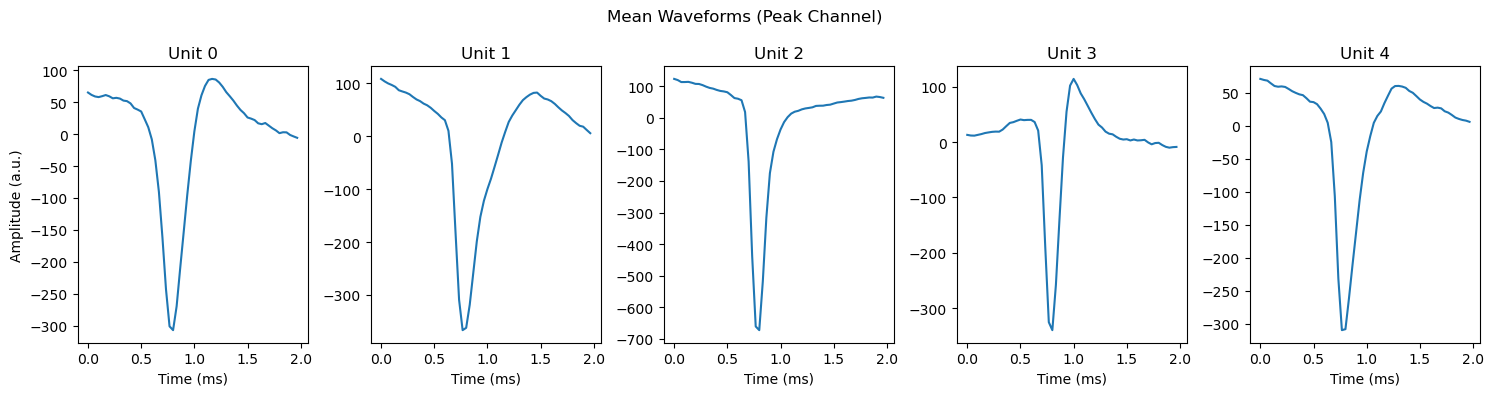

In [13]:
# Plot mean waveforms for the first 5 units
number_of_units_to_plot = min(5, len(units_df))
fig, axes = plt.subplots(1, number_of_units_to_plot, figsize=(15, 4))
for i in range(number_of_units_to_plot):
    waveform = units_df.iloc[i]["waveform_mean"]
    sampling_rate = units_df.iloc[i]["sampling_rate"]
    time_axis = np.arange(waveform.shape[0]) / sampling_rate * 1000  # convert to ms
    # Plot the channel with the largest amplitude
    peak_channel = np.nanargmax(np.nanmax(np.abs(waveform), axis=0))
    axes[i].plot(time_axis, waveform[:, peak_channel])
    axes[i].set_title(f"Unit {units_df.index[i]}")
    axes[i].set_xlabel("Time (ms)")
    if i == 0:
        axes[i].set_ylabel("Amplitude (a.u.)")
plt.suptitle("Mean Waveforms (Peak Channel)")
plt.tight_layout()

# Histology images <a id="histology"></a>

Histology images of probe tracks are stored in `nwbfile.acquisition["histology_images"]`.

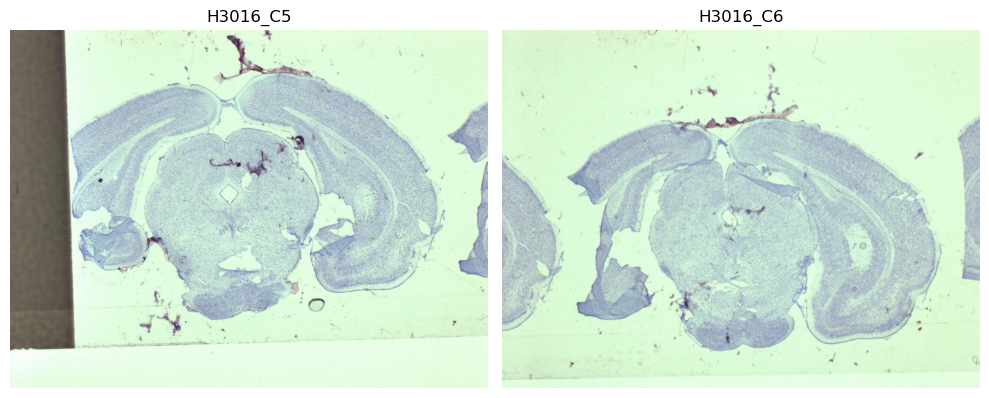

In [14]:
histology_images = nwbfile.acquisition["histology_images"]
number_of_images = len(histology_images.images)
fig, axes = plt.subplots(1, number_of_images, figsize=(5 * number_of_images, 5))
if number_of_images == 1:
    axes = [axes]
for ax, image in zip(axes, histology_images.images.values()):
    ax.imshow(image.data[:])
    ax.set_title(image.name)
    ax.axis("off")
plt.tight_layout()

In [15]:
io.close()